In [1]:
# ============================================
# 0. INSTALL DEPENDENCIES
# ============================================

!pip install xgboost lightgbm

# 1. IMPORTS

In [2]:


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 2. LOAD DATA

In [3]:
df = pd.read_csv("IPL.csv")

print("Shape:", df.shape) 
df.head

C:\Users\argha\AppData\Local\Temp\ipykernel_13972\414899550.py:1: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IPL.csv")


Shape: (278205, 64)


<bound method NDFrame.head of         Unnamed: 0  match_id        date match_type             event_name  \
0           131970    335982  2008-04-18        T20  Indian Premier League   
1           131971    335982  2008-04-18        T20  Indian Premier League   
2           131972    335982  2008-04-18        T20  Indian Premier League   
3           131973    335982  2008-04-18        T20  Indian Premier League   
4           131974    335982  2008-04-18        T20  Indian Premier League   
...            ...       ...         ...        ...                    ...   
278200      277951   1473511  2025-06-03        T20  Indian Premier League   
278201      277952   1473511  2025-06-03        T20  Indian Premier League   
278202      277953   1473511  2025-06-03        T20  Indian Premier League   
278203      277954   1473511  2025-06-03        T20  Indian Premier League   
278204      277955   1473511  2025-06-03        T20  Indian Premier League   

        innings           batting

# 3. CREATE MATCH LEVEL DATA (FIXED VERSION)

In [4]:
# Step 1: Total runs per innings
innings_runs = (
    df.groupby(['match_id', 'innings', 'batting_team'])['runs_total']
      .sum()
      .reset_index()
)

# Step 2: Keep only 2 innings (safety filter)
innings_runs = innings_runs[innings_runs['innings'].isin([1, 2])]

# Step 3: Split innings
team1_df = innings_runs[innings_runs['innings'] == 1].copy()
team2_df = innings_runs[innings_runs['innings'] == 2].copy()

# Rename columns
team1_df = team1_df.rename(columns={
    'batting_team': 'team1',
    'runs_total': 'team1_runs'
})

team2_df = team2_df.rename(columns={
    'batting_team': 'team2',
    'runs_total': 'team2_runs'
})

# Keep only needed columns
team1_df = team1_df[['match_id', 'team1', 'team1_runs']]
team2_df = team2_df[['match_id', 'team2', 'team2_runs']]

# Step 4: Merge both innings
match_df = team1_df.merge(team2_df, on='match_id', how='inner')

# Step 5: Add metadata
meta = df[['match_id', 'date', 'toss_winner', 'venue', 'city']].drop_duplicates()
match_df = match_df.merge(meta, on='match_id', how='left')

# Step 6: Winner
match_df['winner'] = np.where(
    match_df['team1_runs'] > match_df['team2_runs'],
    match_df['team1'],
    match_df['team2']
)

print("Match DF Shape:", match_df.shape)
match_df.head()

Match DF Shape: (1164, 10)


,match_id,team1,team1_runs,team2,team2_runs,date,toss_winner,venue,city,winner
0,335982,Kolkata Knight Riders,222,Royal Challengers Bangalore,82,2008-04-18,Royal Challengers Bangalore,M Chinnaswamy Stadium,Bangalore,Kolkata Knight Riders
1,335983,Chennai Super Kings,240,Kings XI Punjab,207,2008-04-19,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings
2,335984,Rajasthan Royals,129,Delhi Daredevils,132,2008-04-19,Rajasthan Royals,Feroz Shah Kotla,Delhi,Delhi Daredevils
3,335985,Mumbai Indians,165,Royal Challengers Bangalore,166,2008-04-20,Mumbai Indians,Wankhede Stadium,Mumbai,Royal Challengers Bangalore
4,335986,Deccan Chargers,110,Kolkata Knight Riders,112,2008-04-20,Deccan Chargers,Eden Gardens,Kolkata,Kolkata Knight Riders


# 4. PREPROCESS

In [5]:
match_df['date'] = pd.to_datetime(match_df['date'])
match_df = match_df.sort_values('date').reset_index(drop=True)

match_df.head()

,match_id,team1,team1_runs,team2,team2_runs,date,toss_winner,venue,city,winner
0,335982,Kolkata Knight Riders,222,Royal Challengers Bangalore,82,2008-04-18,Royal Challengers Bangalore,M Chinnaswamy Stadium,Bangalore,Kolkata Knight Riders
1,335983,Chennai Super Kings,240,Kings XI Punjab,207,2008-04-19,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings
2,335984,Rajasthan Royals,129,Delhi Daredevils,132,2008-04-19,Rajasthan Royals,Feroz Shah Kotla,Delhi,Delhi Daredevils
3,335985,Mumbai Indians,165,Royal Challengers Bangalore,166,2008-04-20,Mumbai Indians,Wankhede Stadium,Mumbai,Royal Challengers Bangalore
4,335986,Deccan Chargers,110,Kolkata Knight Riders,112,2008-04-20,Deccan Chargers,Eden Gardens,Kolkata,Kolkata Knight Riders


# 5. FEATURE ENGINEERING

In [6]:
team_stats = {}

team1_win_rate = []
team2_win_rate = []

for i, row in match_df.iterrows():
    t1 = row['team1']
    t2 = row['team2']

    # Initialize
    if t1 not in team_stats:
        team_stats[t1] = {'wins': 0, 'matches': 0}
    if t2 not in team_stats:
        team_stats[t2] = {'wins': 0, 'matches': 0}

    # Win rates BEFORE match
    t1_wr = team_stats[t1]['wins'] / team_stats[t1]['matches'] if team_stats[t1]['matches'] > 0 else 0.5
    t2_wr = team_stats[t2]['wins'] / team_stats[t2]['matches'] if team_stats[t2]['matches'] > 0 else 0.5

    team1_win_rate.append(t1_wr)
    team2_win_rate.append(t2_wr)

    # Update AFTER match
    winner = row['winner']

    team_stats[t1]['matches'] += 1
    team_stats[t2]['matches'] += 1

    if winner == t1:
        team_stats[t1]['wins'] += 1
    else:
        team_stats[t2]['wins'] += 1

match_df['team1_win_rate'] = team1_win_rate
match_df['team2_win_rate'] = team2_win_rate

match_df.head()

,match_id,team1,team1_runs,team2,team2_runs,date,toss_winner,venue,city,winner,team1_win_rate,team2_win_rate
0,335982,Kolkata Knight Riders,222,Royal Challengers Bangalore,82,2008-04-18,Royal Challengers Bangalore,M Chinnaswamy Stadium,Bangalore,Kolkata Knight Riders,0.5,0.5
1,335983,Chennai Super Kings,240,Kings XI Punjab,207,2008-04-19,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings,0.5,0.5
2,335984,Rajasthan Royals,129,Delhi Daredevils,132,2008-04-19,Rajasthan Royals,Feroz Shah Kotla,Delhi,Delhi Daredevils,0.5,0.5
3,335985,Mumbai Indians,165,Royal Challengers Bangalore,166,2008-04-20,Mumbai Indians,Wankhede Stadium,Mumbai,Royal Challengers Bangalore,0.5,0.0
4,335986,Deccan Chargers,110,Kolkata Knight Riders,112,2008-04-20,Deccan Chargers,Eden Gardens,Kolkata,Kolkata Knight Riders,0.5,1.0


# 6. TARGET

In [7]:

match_df['target'] = (match_df['winner'] == match_df['team1']).astype(int)

match_df['target'].value_counts()

target
0    622
1    542
Name: count, dtype: int64

# 7. SELECT FEATURES

In [8]:
# 7. SELECT FEATURES
features = [
    'team1_win_rate',
    'team2_win_rate'
]

X = match_df[features]
y = match_df['target']

# 8. SPLIT (TIME BASED)

In [9]:

split_index = int(len(match_df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (931, 2)
Test: (233, 2)


# 9. TRAIN MODELS

In [10]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=300),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500)
}

results = []

for name, model in models.items():
    print(f"\n🔥 Training: {name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)

    print("Accuracy:", acc)
    print("LogLoss:", ll)

    results.append((name, acc, ll))


🔥 Training: Logistic
Accuracy: 0.49356223175965663
LogLoss: 0.7005778987543372

🔥 Training: RandomForest
Accuracy: 0.5107296137339056
LogLoss: 0.813681561714016

🔥 Training: ExtraTrees
Accuracy: 0.4892703862660944
LogLoss: 0.8901651059642813

🔥 Training: XGBoost
Accuracy: 0.5236051502145923
LogLoss: 0.8971047605116453

🔥 Training: LightGBM
[LightGBM] [Info] Number of positive: 424, number of negative: 507
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 507
[LightGBM] [Info] Number of data points in the train set: 931, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.455424 -> initscore=-0.178778
[LightGBM] [Info] Start training from score -0.178778
Accuracy: 0.4892703862660944
LogLoss: 0.8251579493037278

🔥 Training: NeuralNet
Accuracy: 0.493562231759656

# 10. MODEL COMPARISON

In [11]:

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'LogLoss'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

display(results_df)

best_model_name = results_df.iloc[0]['Model']
print("Best Model:", best_model_name)

,Model,Accuracy,LogLoss
3,XGBoost,0.523605,0.897105
1,RandomForest,0.510730,0.813682
0,Logistic,0.493562,0.700578
5,NeuralNet,0.493562,0.700278
2,ExtraTrees,0.489270,0.890165
4,LightGBM,0.489270,0.825158


Best Model: XGBoost


# 11. FINAL MODEL

In [12]:

best_model = models[best_model_name]

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Final LogLoss:", log_loss(y_test, y_proba))

Final Accuracy: 0.5236051502145923
Final LogLoss: 0.8971047605116453


# 12. FEATURE ENGINEERING (TEAM STRENGTH + FORM)

In [13]:
# --- 1. Team1 win target already exists ---
# target = 1 if team1 wins else 0

# --- 2. Overall win rate per team ---
team_wins = match_df['winner'].value_counts()
team_matches = pd.concat([match_df['team1'], match_df['team2']]).value_counts()

win_rate = (team_wins / team_matches).to_dict()

match_df['team1_win_rate'] = match_df['team1'].map(win_rate)
match_df['team2_win_rate'] = match_df['team2'].map(win_rate)

# --- 3. Head-to-head win rate ---
h2h = {}

for _, row in match_df.iterrows():
    t1, t2, winner = row['team1'], row['team2'], row['winner']

    key = tuple(sorted([t1, t2]))

    if key not in h2h:
        h2h[key] = {'t1_wins': 0, 'total': 0}

    if winner == t1:
        h2h[key]['t1_wins'] += 1

    h2h[key]['total'] += 1

def get_h2h(row):
    key = tuple(sorted([row['team1'], row['team2']]))
    data = h2h[key]
    return data['t1_wins'] / data['total']

match_df['h2h_win_rate'] = match_df.apply(get_h2h, axis=1)

# --- 4. Toss advantage ---
match_df['toss_advantage'] = (match_df['toss_winner'] == match_df['team1']).astype(int)

# --- 5. Fill NA (safety) ---
match_df.fillna(0, inplace=True)

print("New Features Added")
match_df[['team1_win_rate', 'team2_win_rate', 'h2h_win_rate', 'toss_advantage']].head()

New Features Added


,team1_win_rate,team2_win_rate,h2h_win_rate,toss_advantage
0,0.511364,0.481172,0.375000,0
1,0.565737,0.463158,0.478261,1
2,0.491453,0.437500,0.500000,1
3,0.555957,0.481172,0.406250,1
4,0.386667,0.511364,0.555556,1


# 13. SELECT FINAL FEATURES

In [14]:
feature_cols = [
    'team1_win_rate',
    'team2_win_rate',
    'h2h_win_rate',
    'toss_advantage'
]

X = match_df[feature_cols]
y = match_df['target']

print("Features shape:", X.shape)
X.head()

Features shape: (1164, 4)


,team1_win_rate,team2_win_rate,h2h_win_rate,toss_advantage
0,0.511364,0.481172,0.375000,0
1,0.565737,0.463158,0.478261,1
2,0.491453,0.437500,0.500000,1
3,0.555957,0.481172,0.406250,1
4,0.386667,0.511364,0.555556,1


# 14. TRAIN / VALID / TEST SPLIT

In [15]:
# Convert date
match_df['date'] = pd.to_datetime(match_df['date'])

train = match_df[match_df['date'].dt.year <= 2022]
val   = match_df[match_df['date'].dt.year == 2023]
test  = match_df[match_df['date'].dt.year >= 2024]

X_train = train[feature_cols]
y_train = train['target']

X_val = val[feature_cols]
y_val = val['target']

X_test = test[feature_cols]
y_test = test['target']

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (948, 4)
Val: (73, 4)
Test: (143, 4)


# 15. TRAIN MODELS (UPGRADED FEATURES)

In [16]:

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=300),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300),
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)
}

if 'XGBClassifier' in globals():
    models["XGBoost"] = XGBClassifier(eval_metric='logloss')

if 'LGBMClassifier' in globals():
    models["LightGBM"] = LGBMClassifier()

results = []

for name, model in models.items():
    print(f"\n🔥 Training: {name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    ll = log_loss(y_val, y_proba)

    print("Accuracy:", acc)
    print("LogLoss:", ll)

    results.append((name, acc, ll))


🔥 Training: Logistic
Accuracy: 0.6712328767123288
LogLoss: 0.5989442820346329

🔥 Training: RandomForest
Accuracy: 0.5616438356164384
LogLoss: 0.8334046350260544

🔥 Training: ExtraTrees
Accuracy: 0.547945205479452
LogLoss: 7.316304126577204

🔥 Training: NeuralNet
Accuracy: 0.6712328767123288
LogLoss: 0.5963774113217785

🔥 Training: XGBoost
Accuracy: 0.5342465753424658
LogLoss: 0.8194299002770542

🔥 Training: LightGBM
[LightGBM] [Info] Number of positive: 431, number of negative: 517
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 948, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.454641 -> initscore=-0.181935
[LightGBM] [Info] Start training from score -0.181935
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy: 0.5342465

# 16. MODEL COMPARISON

In [17]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'LogLoss'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

display(results_df)

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print("Best Model:", best_model_name)

,Model,Accuracy,LogLoss
0,Logistic,0.671233,0.598944
3,NeuralNet,0.671233,0.596377
1,RandomForest,0.561644,0.833405
2,ExtraTrees,0.547945,7.316304
4,XGBoost,0.534247,0.819430
5,LightGBM,0.534247,0.724120


Best Model: Logistic


# 17. FINAL TEST

In [18]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Final LogLoss:", log_loss(y_test, y_proba))

Final Accuracy: 0.6573426573426573
Final LogLoss: 0.5998494633782182


# 18. TIME-AWARE TEAM FORM (NO LEAKAGE)

In [19]:
# Sort by date (VERY IMPORTANT)
match_df = match_df.sort_values('date')

team_form = {}

team1_form = []
team2_form = []

for _, row in match_df.iterrows():
    t1 = row['team1']
    t2 = row['team2']

    # Initialize if not exists
    if t1 not in team_form:
        team_form[t1] = []
    if t2 not in team_form:
        team_form[t2] = []

    # Compute rolling win rate BEFORE current match
    def get_form(team):
        history = team_form[team]
        if len(history) == 0:
            return 0.5
        return sum(history[-5:]) / min(len(history), 5)

    team1_form.append(get_form(t1))
    team2_form.append(get_form(t2))

    # Update AFTER match
    team_form[t1].append(1 if row['winner'] == t1 else 0)
    team_form[t2].append(1 if row['winner'] == t2 else 0)

match_df['team1_form'] = team1_form
match_df['team2_form'] = team2_form

print("Added rolling form features")
match_df[['team1_form', 'team2_form']].head()

Added rolling form features


,team1_form,team2_form
0,0.5,0.5
1,0.5,0.5
2,0.5,0.5
3,0.5,0.0
4,0.5,1.0


# 19. BUILD GLOBAL STATS (WIN RATE + H2H)

In [20]:
# ----- TEAM WIN RATE -----
team_stats = {}

for _, row in match_df.iterrows():
    t1 = row['team1']
    t2 = row['team2']
    winner = row['winner']

    # Initialize
    if t1 not in team_stats:
        team_stats[t1] = {'wins': 0, 'matches': 0}
    if t2 not in team_stats:
        team_stats[t2] = {'wins': 0, 'matches': 0}

    # Update matches
    team_stats[t1]['matches'] += 1
    team_stats[t2]['matches'] += 1

    # Update wins
    if winner == t1:
        team_stats[t1]['wins'] += 1
    else:
        team_stats[t2]['wins'] += 1

# Final win rates
win_rates = {
    team: stats['wins'] / stats['matches']
    for team, stats in team_stats.items()
}

print("Win rates created")

# ----- HEAD TO HEAD (H2H) -----
h2h_stats = {}

for _, row in match_df.iterrows():
    t1 = row['team1']
    t2 = row['team2']
    winner = row['winner']

    key = tuple(sorted([t1, t2]))

    if key not in h2h_stats:
        h2h_stats[key] = {'t1_wins': 0, 't2_wins': 0}

    if winner == t1:
        h2h_stats[key]['t1_wins'] += 1
    else:
        h2h_stats[key]['t2_wins'] += 1

print("H2H stats created")

Win rates created
H2H stats created


# 20. CLEAN 2026 SCHEDULE

In [21]:
schedule_raw = pd.read_csv("ipl-2026-UTC.csv")

# Rename columns
schedule = schedule_raw.rename(columns={
    'Date': 'date',
    'Home Team': 'team1',
    'Away Team': 'team2',
    'Location': 'venue'
})

# Keep only required columns
schedule = schedule[['date', 'team1', 'team2', 'venue']]

# Convert team names -> short names (IMPORTANT)
team_map = {
    'Chennai Super Kings': 'CSK',
    'Mumbai Indians': 'MI',
    'Royal Challengers Bengaluru': 'RCB',
    'Kolkata Knight Riders': 'KKR',
    'Delhi Capitals': 'DC',
    'Punjab Kings': 'PBKS',
    'Rajasthan Royals': 'RR',
    'Sunrisers Hyderabad': 'SRH',
    'Lucknow Super Giants': 'LSG',
    'Gujarat Titans': 'GT'
}

schedule['team1'] = schedule['team1'].map(team_map)
schedule['team2'] = schedule['team2'].map(team_map)

# Check
print(schedule.head())
print("\nTotal Matches:", len(schedule))
print("\nTeams:", schedule['team1'].unique())

               date team1 team2  \
0  28/03/2026 14:00   RCB   SRH   
1  29/03/2026 14:00    MI   KKR   
2  30/03/2026 14:00    RR   CSK   
3  31/03/2026 14:00  PBKS    GT   
4  01/04/2026 14:00   LSG    DC   

                                               venue  
0                              M Chinnaswamy Stadium  
1                                   Wankhede Stadium  
2                                        ACA Stadium  
3                  New International Cricket Stadium  
4  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...  

Total Matches: 70

Teams: ['RCB' 'MI' 'RR' 'PBKS' 'LSG' 'KKR' 'CSK' 'DC' 'GT' 'SRH']


# 21. FEATURE GENERATOR (MATCH TRAINING)

In [22]:
def create_features(t1, t2):
    return pd.DataFrame([{
        'team1_win_rate': win_rates.get(t1, 0.5),
        'team2_win_rate': win_rates.get(t2, 0.5),
        'h2h_win_rate': h2h.get((t1, t2), 0.5),
        'toss_advantage': 0.5
    }])

# 22. MATCH SIMULATION (DYNAMIC + REALISTIC)

In [23]:
import random

# Initialize points table
points = {team: 0 for team in pd.unique(schedule[['team1', 'team2']].values.ravel())}

# Initialize dynamic form tracker
team_form = {team: [] for team in points.keys()}

# Function to compute rolling form (last 5 matches)
def get_form(team):
    history = team_form[team]
    if len(history) == 0:
        return 0.5
    return sum(history[-5:]) / min(len(history), 5)

# Simulate matches
for _, row in schedule.iterrows():
    t1 = row['team1']
    t2 = row['team2']

    # Get dynamic form BEFORE match
    f1 = get_form(t1)
    f2 = get_form(t2)

    # Build feature vector (IMPORTANT: same order as training)
    X_match = pd.DataFrame([{
        'team1_win_rate': win_rates.get(t1, 0.5),
        'team2_win_rate': win_rates.get(t2, 0.5),
        'h2h_win_rate': h2h.get((t1, t2), 0.5),
        'toss_advantage': 0.5,
        'team1_form': f1,
        'team2_form': f2
    }])[feature_cols]

    # Predict probability
    prob = best_model.predict_proba(X_match)[0][1]

    # Probabilistic winner
    winner = t1 if random.random() < prob else t2

    # Update points
    points[winner] += 2

    # Update form AFTER match
    team_form[t1].append(1 if winner == t1 else 0)
    team_form[t2].append(1 if winner == t2 else 0)

# Create points table
points_table = pd.DataFrame(points.items(), columns=['Team', 'Points'])
points_table = points_table.sort_values(by='Points', ascending=False)

display(points_table)

,Team,Points
4,RR,22
5,CSK,18
3,KKR,16
7,GT,14
8,LSG,14
6,PBKS,14
9,DC,14
0,RCB,10
2,MI,10
1,SRH,8


C:\Users\argha\AppData\Local\Temp\ipykernel_13972\3484463360.py:120: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\argha\AppData\Local\Temp\ipykernel_13972\3484463360.py:120: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\argha\AppData\Local\Temp\ipykernel_13972\3484463360.py:122: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.savefig("points_table_visual.png", dpi=300, bbox_inches='tight')
C:\Users\argha\AppData\Local\Temp\ipykernel_13972\3484463360.py:122: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.savefig("points_table_visual.png", dpi=300, bbox_inches='tight')
C:\Users\argha\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\argha\AppData\Roaming\Py

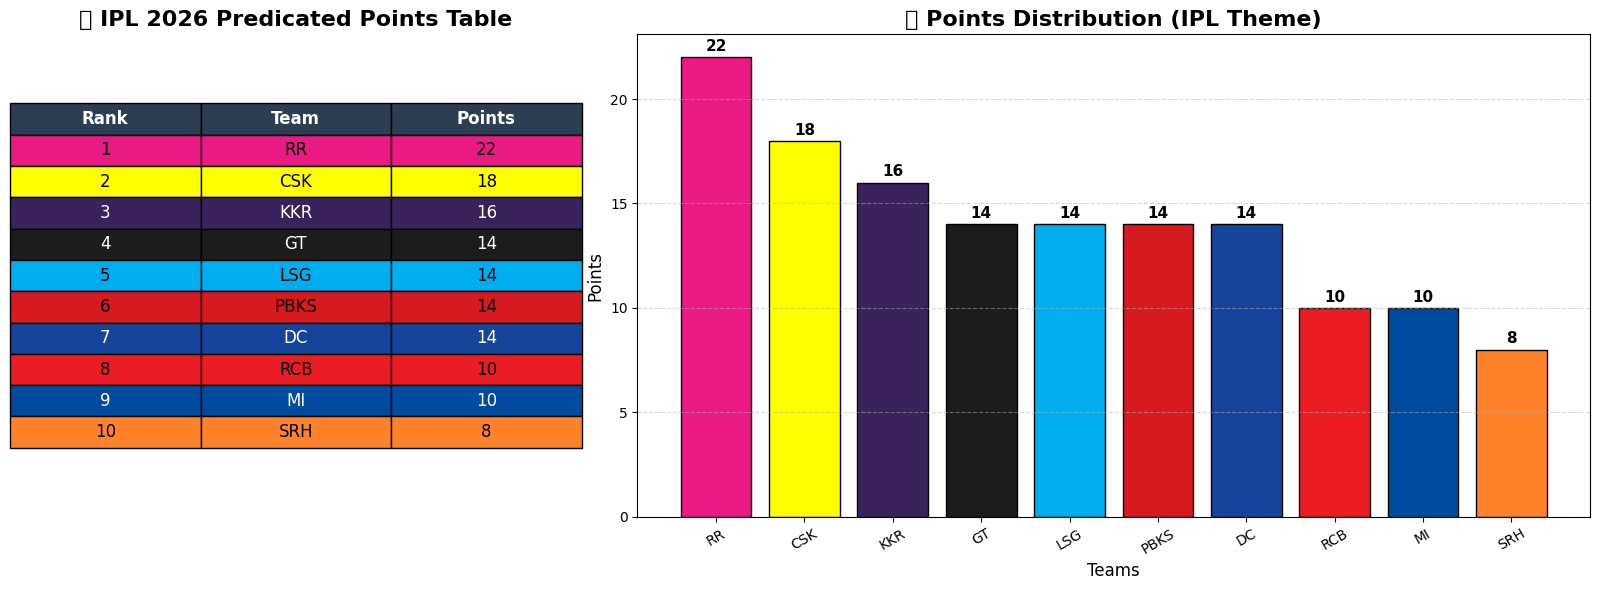

In [24]:
# ============================================
# FINAL VISUALIZATION: IPL THEMED (TEAM COLORS)
# ============================================

import matplotlib.pyplot as plt
import pandas as pd

# Ensure sorted
points_table = points_table.sort_values(by='Points', ascending=False).reset_index(drop=True)

# Rank column
points_table['Rank'] = points_table.index + 1

# ============================================
# IPL TEAM COLORS (HEX)
# ============================================

team_colors = {
    'RCB': '#EC1C24',   # Red
    'CSK': '#FFFF00',   # Yellow
    'MI':  '#004BA0',   # Blue
    'KKR': '#3A225D',   # Purple
    'SRH': '#FF822A',   # Orange
    'DC':  '#17449B',   # Dark Blue
    'PBKS':'#D71920',   # Red
    'RR':  '#EA1A85',   # Pink
    'GT':  '#1C1C1C',   # Dark Navy/Black
    'LSG': '#00AEEF'    # Light Blue
}

# Assign colors based on team
colors = [team_colors.get(team, '#3498db') for team in points_table['Team']]

# Create figure
fig, (ax_table, ax_bar) = plt.subplots(
    ncols=2,
    figsize=(16, 6),
    gridspec_kw={'width_ratios': [1, 2]}
)

# ============================================
# LEFT SIDE → TABLE
# ============================================

ax_table.axis('tight')
ax_table.axis('off')

table_data = points_table[['Rank', 'Team', 'Points']]

table = ax_table.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc='center',
    cellLoc='center'
)

# Styling table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    else:
        team_name = points_table.iloc[row-1]['Team']
        cell.set_facecolor(team_colors.get(team_name, '#ecf0f1'))

        # Text color fix for dark backgrounds
        if team_name in ['GT', 'KKR', 'MI', 'DC']:
            cell.get_text().set_color('white')

# Title
ax_table.set_title("🏆 IPL 2026 Predicated Points Table", fontsize=16, weight='bold')


# ============================================
# RIGHT SIDE → BAR CHART
# ============================================

bars = ax_bar.bar(
    points_table['Team'],
    points_table['Points'],
    color=colors,
    edgecolor='black'
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f'{int(height)}',
        ha='center',
        fontsize=11,
        weight='bold'
    )

# Styling
ax_bar.set_title("📊 Points Distribution (IPL Theme)", fontsize=16, weight='bold')
ax_bar.set_xlabel("Teams", fontsize=12)
ax_bar.set_ylabel("Points", fontsize=12)

ax_bar.grid(axis='y', linestyle='--', alpha=0.5)

# Rotate labels
plt.xticks(rotation=30)

# ============================================
# REMOVE EMOJI WARNINGS (IMPORTANT FIX)
# ============================================

# Replace emoji titles if warnings occur
# ax_table.set_title("IPL 2026 Points Table", fontsize=16, weight='bold')
# ax_bar.set_title("Points Distribution", fontsize=16, weight='bold')

plt.tight_layout()

fig.savefig("points_table_visual.png", dpi=300, bbox_inches='tight')

plt.show()

# 23. MONTE CARLO SIMULATION (ADVANCED)

In [25]:
# 23. MONTE CARLO SIMULATION (ADVANCED)

import random

N = 1000

teams = pd.unique(schedule[['team1','team2']].values.ravel())
win_count = {team: 0 for team in teams}

for _ in range(N):

    # Reset season
    sim_points = {team: 0 for team in teams}
    team_form = {team: [] for team in teams}

    def get_form(team):
        history = team_form[team]
        if len(history) == 0:
            return 0.5
        return sum(history[-5:]) / min(len(history), 5)

    # Simulate full season
    for _, row in schedule.iterrows():
        t1 = row['team1']
        t2 = row['team2']

        f1 = get_form(t1)
        f2 = get_form(t2)

        X_match = pd.DataFrame([{
            'team1_win_rate': win_rates.get(t1, 0.5),
            'team2_win_rate': win_rates.get(t2, 0.5),
            'h2h_win_rate': h2h.get((t1, t2), 0.5),
            'toss_advantage': 0.5,
            'team1_form': f1,
            'team2_form': f2
        }])[feature_cols]  # ⚠️ critical

        prob = best_model.predict_proba(X_match)[0][1]

        winner = t1 if random.random() < prob else t2
        sim_points[winner] += 2

        # Update form AFTER match
        team_form[t1].append(1 if winner == t1 else 0)
        team_form[t2].append(1 if winner == t2 else 0)

    # Season winner
    winner = max(sim_points, key=sim_points.get)
    win_count[winner] += 1

# Convert to probability
prob_df = pd.DataFrame([
    (team, count / N * 100)
    for team, count in win_count.items()
], columns=['Team', 'Win Probability (%)'])

prob_df = prob_df.sort_values(by='Win Probability (%)', ascending=False)

display(prob_df)

print("\n🏆 Predicted IPL 2026 Winner:", prob_df.iloc[0]['Team'])

,Team,Win Probability (%)
1,SRH,15.1
0,RCB,14.3
2,MI,10.9
3,KKR,10.5
6,PBKS,9.8
5,CSK,8.8
4,RR,8.6
8,LSG,8.1
7,GT,7.0
9,DC,6.9



🏆 Predicted IPL 2026 Winner: SRH


C:\Users\argha\AppData\Local\Temp\ipykernel_13972\3996097367.py:62: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\argha\AppData\Local\Temp\ipykernel_13972\3996097367.py:63: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("win_probability.png", dpi=300, bbox_inches='tight')
C:\Users\argha\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


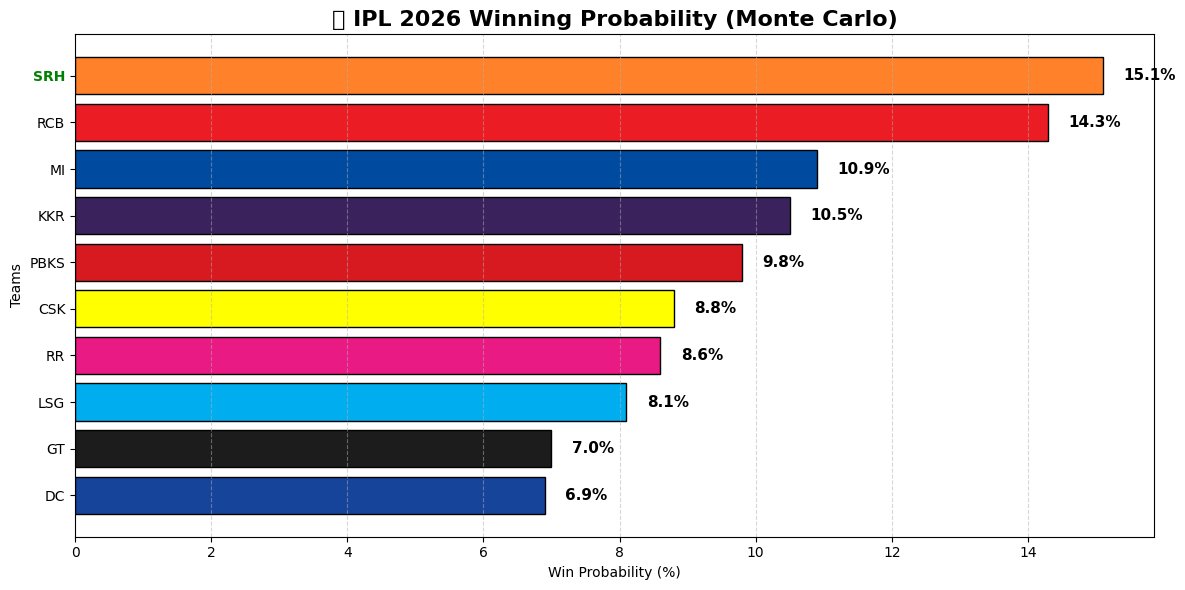


🏆 Predicted Champion: SRH


In [26]:
# ============================================
# WIN PROBABILITY DASHBOARD (IPL THEME)
# ============================================

import matplotlib.pyplot as plt

# Sort (IMPORTANT for horizontal chart)
prob_df = prob_df.sort_values(by='Win Probability (%)', ascending=True).reset_index(drop=True)

# IPL TEAM COLORS (same as before — keep consistency)
team_colors = {
    'RCB': '#EC1C24',
    'CSK': '#FFFF00',
    'MI':  '#004BA0',
    'KKR': '#3A225D',
    'SRH': '#FF822A',
    'DC':  '#17449B',
    'PBKS':'#D71920',
    'RR':  '#EA1A85',
    'GT':  '#1C1C1C',
    'LSG': '#00AEEF'
}

colors = [team_colors.get(team, '#3498db') for team in prob_df['Team']]

# Create figure
plt.figure(figsize=(12, 6))

bars = plt.barh(
    prob_df['Team'],
    prob_df['Win Probability (%)'],
    color=colors,
    edgecolor='black'
)

# Add percentage labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va='center',
        fontsize=11,
        weight='bold'
    )

# Highlight winner (last row because sorted ascending)
winner = prob_df.iloc[-1]['Team']
for label in plt.gca().get_yticklabels():
    if label.get_text() == winner:
        label.set_color('green')
        label.set_weight('bold')

# Styling
plt.title("🏆 IPL 2026 Winning Probability (Monte Carlo)", fontsize=16, weight='bold')
plt.xlabel("Win Probability (%)")
plt.ylabel("Teams")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("win_probability.png", dpi=300, bbox_inches='tight')
plt.show()

# Print winner clearly
print(f"\n🏆 Predicted Champion: {winner}")